In [54]:
#autoreload
%load_ext autoreload
%autoreload 2
import torch
import matplotlib.pyplot as plt
import numpy as np
import featureman.gen_data as man
import featureman.utils as utils
from sklearn.cluster import SpectralClustering
import pickle
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
sae_dict = torch.load("sae_model_small_batch_2025-08-07_00-27-27.pth", map_location=device)
sae = man.BatchedSAE_Updated(input_dim=512, n_models=5, width_ratio=4).to(device)
sae.load_state_dict(sae_dict)

model_dict = torch.load("modular_arithmetic_model.pth", map_location=device)
model = man.OneLayerTransformer(p=113, d_model=128, nheads=4).to(device)
model.load_state_dict(model_dict)

<All keys matched successfully>

In [56]:
torch.manual_seed(1337)
# generate combination of all inputs a and b range (113)
a_values = np.arange(113)
b_values = np.arange(113)
# generate inputs for the model
inputs = np.array([[a_i, 113, b_i, 114] for a_i in a_values for b_i in b_values])
inputs = torch.tensor(inputs).to(device)  # Add batch dimension

logits, activations = model(inputs, return_activations=True)
activation_final = activations[:, -1, :].detach()
batched_acts = activation_final.unsqueeze(0).repeat(5, 1, 1).to(device)

In [57]:
import pickle

decoder = sae.W_d[3].detach() #2048 x 512
bias_d = sae.b_d[3]

_, _, feat_acts, _ = sae(batched_acts)
features = feat_acts[3].detach() # 12769 x 512
with open("sae_clusters_small_batch_15.pkl", "rb") as f:
    clusters = pickle.load(f)
    clusters = [c for c in clusters if len(c) > 1]  # Filter out clusters with only one element

clusters = sorted(clusters, key=lambda x: len(x), reverse=True)  # Sort by size

decoder_norms = torch.norm(decoder, dim=1).cpu().numpy()

In [58]:
#for any decoder_norm < 0.4 set decoer to 0
decoder_filtered = decoder.clone()
decoder_filtered[decoder_norms < 0.6] = 0

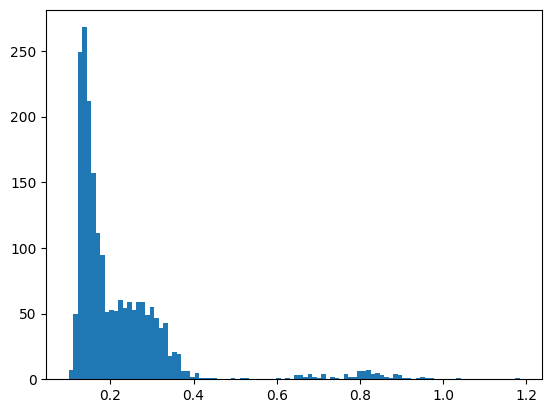

In [59]:
decoder_filtered_norms = torch.norm(decoder_filtered, dim=1).cpu().numpy()
plt.hist(decoder_norms, bins=100);

In [60]:
reconstructions = features @ decoder + bias_d
reconstructions_filtered = features @ decoder_filtered + bias_d

#mse between the two reconstructions
mse = torch.mean((reconstructions - reconstructions_filtered) ** 2).item()
print(f"MSE between original and filtered reconstructions: {mse}")
# between reconstruction and activations
mse = torch.mean((reconstructions - batched_acts[3]) ** 2).item()
print(f"MSE between reconstruction and activations: {mse}")
# between filtered reconstruction and activations
mse = torch.mean((reconstructions_filtered - batched_acts[3]) ** 2).item()
print(f"MSE between filtered reconstruction and activations: {mse}")

MSE between original and filtered reconstructions: 0.0035485276021063328
MSE between reconstruction and activations: 0.2943856120109558
MSE between filtered reconstruction and activations: 0.3095954358577728


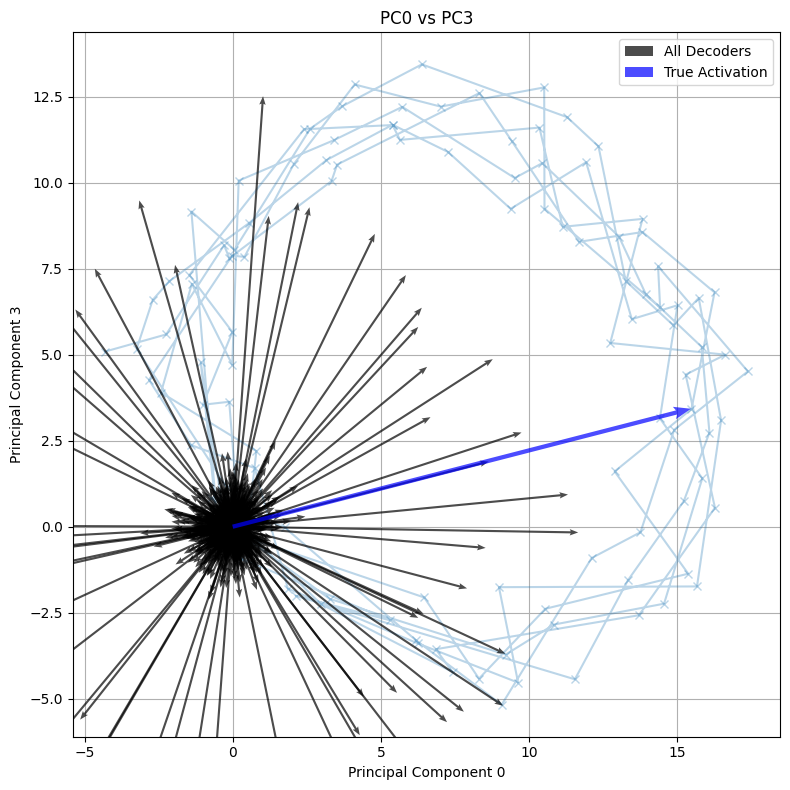

In [61]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

bias_d = bias_d.detach().cpu().numpy()  # Convert bias to numpy for later use

#------------------------------------------------------------
#| Define Decoder and Reconstruction Vectors and Projections|
#------------------------------------------------------------

#full reconstruction
reconstructions = features @ decoder #12769, 2048 @ 2048, 512 -> 12769, 512

#Define specific activation for a=8, b=11
feat_i = 8*113+11
features_interest = features[feat_i].unsqueeze(1) #2048, 1
#the individual decoders for this sparse code scaled by those respective codes
single_recon_scaled_decoders = features_interest * decoder #2048, 512
#single reconstruction for a=8, b=11
single_recon = features[feat_i] @ decoder_filtered #512,
#original decoders used for the reconstruction of a=8, b=11
feat_mask = features_interest > 1e-3
masked_decoder = feat_mask * decoder_filtered

#add in the bias
reconstructions_w_bd = reconstructions.detach().cpu().numpy() + bias_d
single_recon_scaled_decoders_w_bd = single_recon_scaled_decoders.detach().cpu().numpy() + bias_d
single_recon_w_bd = single_recon.detach().cpu().numpy() + bias_d
single_recon_w_bd = single_recon_w_bd.reshape(1,-1) #1, 512
masked_decoder_w_bd = masked_decoder.detach().cpu().numpy() + bias_d

#construct the reconstructions PCA
pca_sae = PCA(n_components=6).fit(reconstructions_w_bd)
output_pca_sae = pca_sae.transform(reconstructions_w_bd)

#project decoders for the single reconstruction
projected_scaled_decoders = pca_sae.transform(single_recon_scaled_decoders_w_bd)

#project single reconstruction
projected_single_recon = pca_sae.transform(single_recon_w_bd)

#project specific decoders used for single reconstruction
projected_masked_decoders = decoder.detach().cpu().numpy() @ pca_sae.components_.T

#------------------------
#| Plot the Projections |
#------------------------
#plot the projected reconstructions for a = 8
plt.figure(figsize=(8,8))
for a in [8]:
    plt.plot(output_pca_sae[:, 0][a*113:a*113+113], output_pca_sae[:, 3][a*113:a*113+113], marker='x', alpha=0.3)

#plot the directions of the relevant decoder vectors scaled for visualization
extended_vectors = projected_masked_decoders * 0.3

origins_x = np.zeros(len(projected_masked_decoders))
origins_y = np.zeros(len(projected_masked_decoders))

plt.quiver(origins_x, origins_y, 
           projected_masked_decoders[:, 0], projected_masked_decoders[:, 3], 
           scale=1,  # Try scale=1 instead of scale=None
           color='black', alpha=0.7, width=0.003,
           headwidth=3, headlength=4, headaxislength=3.5,
           label=f'All Decoders',
           zorder=22)

#plot the directions of the activation scaled decoder vectors
extended_vectors = projected_scaled_decoders * 0.1

origins_x = np.zeros(len(projected_scaled_decoders))
origins_y = np.zeros(len(projected_scaled_decoders))

'''plt.quiver(origins_x, origins_y, 
           extended_vectors[:, 0], extended_vectors[:, 3], 
           scale=1,  # Try scale=1 instead of scale=None
           color='red', alpha=0.7, width=0.003,
           headwidth=3, headlength=4, headaxislength=3.5,
           label=f'Activated Features (element product - scaled)',
           zorder=22)'''

#plot the actual reconstructed vector
plt.quiver(0, 0, 
           projected_single_recon[:, 0], projected_single_recon[:, 3], 
           angles='xy', scale_units='xy', scale=1,
           label=f'True Activation', color='blue',alpha=0.7, width=0.006,
           headwidth=3, headlength=4, headaxislength=3.5,
           zorder=23)

plt.title("PC0 vs PC3")
plt.xlabel("Principal Component 0")
plt.ylabel("Principal Component 3")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


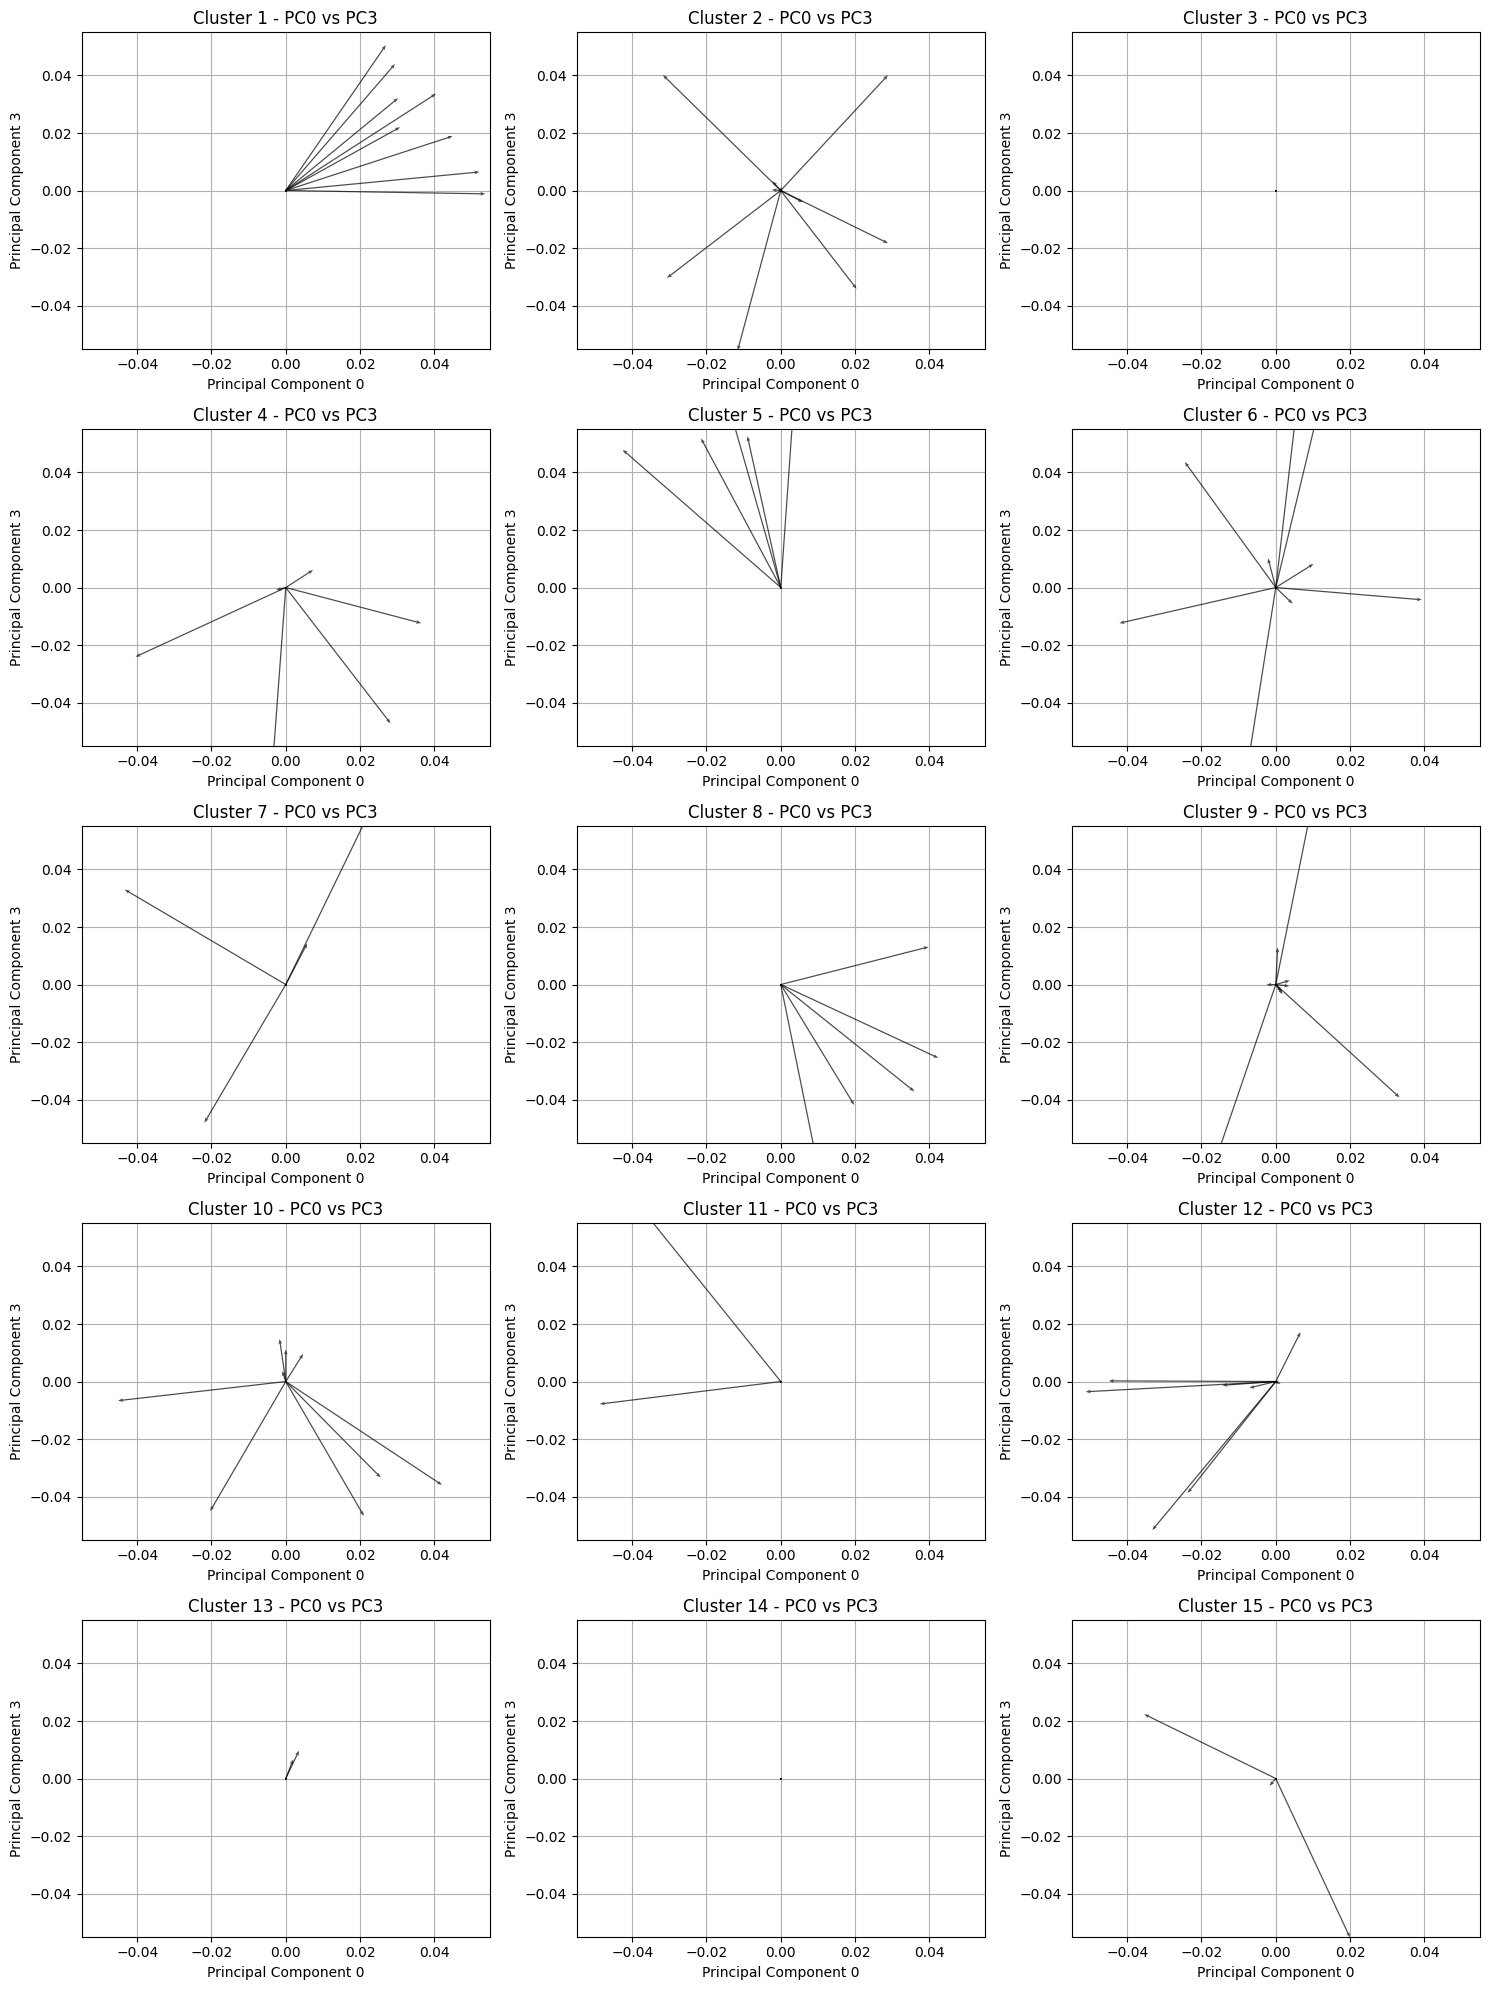

In [66]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

#------------------------------------------------------------
#| Define Decoder and Reconstruction Vectors and Projections|
#------------------------------------------------------------

#full reconstruction
reconstructions = features @ decoder #12769, 2048 @ 2048, 512 -> 12769, 512

#construct the reconstructions PCA
pca_sae = PCA(n_components=6).fit(reconstructions_w_bd)
output_pca_sae = pca_sae.transform(reconstructions_w_bd)

#------------------------
#| Plot the Projections |
#------------------------
colors = sns.color_palette('husl', 15)
#plot the projected reconstructions for a = 8
fig, axes = plt.subplots(5,3, figsize=(15,20))
'''for a in range(20):
    plt.plot(output_pca_sae[:, 0][a*113:a*113+113], output_pca_sae[:, 3][a*113:a*113+113], marker='x', alpha=0.3)'''

for i, ax in enumerate(axes.flatten()):
    cluster_decoder = decoder_filtered[clusters[i], :].detach().cpu().numpy()
    projected_cluster = cluster_decoder @ pca_sae.components_.T
    #plot the directions of the relevant decoder vectors scaled for visualization
    extended_vectors = projected_cluster * 0.3

    origins_x = np.zeros(len(projected_cluster))
    origins_y = np.zeros(len(projected_cluster))

    color = colors[i % len(colors)]

    ax.quiver(origins_x, origins_y, 
            projected_cluster[:, 0], projected_cluster[:, 3], 
            scale=1,  # Try scale=1 instead of scale=None
            color='black', alpha=0.7, width=0.003,
            headwidth=3, headlength=4, headaxislength=3.5,
            label=f'Cluster {i}',
            zorder=22)

    ax.set_title(f"Cluster {i+1} - PC0 vs PC3")
    ax.set_xlabel("Principal Component 0")
    ax.set_ylabel("Principal Component 3")
    ax.grid()
plt.tight_layout()
plt.show()
